# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [1]:
# Import necessary libraries for data manipulation, model building, and evaluation

from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

from evaluationFuncs import mape, rmse, direction_accuracy

from modelFuncs import dataExtracterMonths, dataExtracterDays, HMMPricePredictor

## Load and Prepare Data

In this section, we load the data and preprocess it for modeling.


In [2]:
df_nvo = dataExtracterDays('NVO', '2016-01-01', '2026-01-01')
df_nvo['Return'] = df_nvo['Close'].pct_change()
df_nvo =df_nvo.dropna()

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [3]:
def HMM_predictBroadcast(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    
    print(means*100)
    print(np.round(model.transmat_, 2))
    
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    doprint = True
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        state_probs = model.predict_proba(window)[-1]

        # Expected distribution of hidden states for next step
        next_state_probs = state_probs @ model.transmat_

        # Expected return across all states
        predicted_return = np.dot(next_state_probs, means)
        
        if doprint:
            print(f"State probabilities: {np.round(state_probs, 2)}")
            print(f"Next state probabilities: {np.round(next_state_probs, 2)}")
            print(f"Expected return: {predicted_return}")
            doprint = False

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [5]:
df_nvoV2 = df_nvo.copy()
df_nvoV2['Volatility'] = df_nvoV2['Return'].rolling(10).std()
df_nvoV2['Momentum'] = df_nvoV2['Close'].pct_change(5)
df_nvoV2 = df_nvoV2.dropna()

In [6]:
df_nvoV2

,Date,Open,High,Low,Close,Return,Volatility,Momentum
10,2016-01-19,21.714845,21.755297,21.391226,21.520674,0.001506,0.018116,-0.024390
11,2016-01-20,21.172778,21.565166,20.857250,21.395266,-0.005827,0.016862,-0.045824
12,2016-01-21,21.613708,21.735065,21.346722,21.569210,0.008130,0.017652,-0.014964
13,2016-01-22,21.917105,22.248814,21.900923,22.143639,0.026632,0.019691,-0.004003
14,2016-01-25,22.289265,22.588613,22.204315,22.353989,0.009499,0.018519,0.040286
...,...,...,...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001,0.018407,0.028437,0.100272
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002,-0.003044,0.027850,0.100609
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001,-0.017748,0.028685,0.070285
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001,-0.004857,0.028786,0.064865


In [7]:
def HMM_predict_feat(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    features = ['Return', 'Volatility', 'Momentum']
    train_data = train[features].values
    print(np.sum(np.isnan(train_data)))
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("State-wise means:", np.round(means.flatten(), 3))
    print("State-wise std:", stds.flatten())
    print("State counts:", np.bincount(model.predict(train_scaled)))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[features].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Probability distribution of hidden states for current step
        current_state = model.predict(window_scaled)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return_scaled = norm.rvs(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [34]:
def HMM_predict_log_feat(obsData, train_size, window_size, Ncomp, doprint=False, first=False):
    rng = np.random.default_rng(123)
    obs = obsData.copy()
    obs['LogReturn'] = np.log(1 + obs['Return'])
    train = obs[:train_size]
    features = ['LogReturn', 'Volatility', 'Momentum']
    train_data = train[features].values
    
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    if doprint:
        print("State-wise means:", np.round(means.flatten(), 3))
        print("State-wise std:", stds.flatten())
        print("State counts:", np.bincount(model.predict(train_scaled)))
        print(np.sum(np.isnan(train_data)))
        print(np.round(model.transmat_, 2))
        first = True
    
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[features].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Probability distribution of hidden states for current step
        current_state = model.predict(window_scaled)[-1]

        # Expected distribution of hidden states for next step
        next_state = rng.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return_scaled = rng.normal(loc=means[next_state][0], scale=stds[next_state][0])

        dummy = np.zeros((1, len(features)))
        dummy[0, 0] = predicted_return_scaled

        predicted_log_return = scaler.inverse_transform(dummy)[0, 0]
        

        # Convert to price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [9]:
def HMM_predict_sample(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)

        # Probability distribution of hidden states for current step
        current_state = model.predict(window_scaled)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return = scaler.inverse_transform(norm.rvs(loc=means[next_state], scale=stds[next_state], size=1).reshape(-1,1))[0]
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [10]:
def HMM_predict_logsample(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    obs['LogReturn'] = np.log(1 + obs['Return'])
    train = obs[:train_size]
    train_data = train['LogReturn'].values.reshape(-1, 1)
    train_scaled = scaler.fit_transform(train_data)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_scaled)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['LogReturn']].iloc[T-window_size:T].values
        window_scaled = scaler.transform(window)
        
        # Probability distribution of hidden states for current step
        current_state = model.predict(window_scaled)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_log_return = scaler.inverse_transform(norm.rvs(loc=means[next_state], scale=stds[next_state], size=1).reshape(-1,1))[0]
        

        # Convert to price
        last_price = obs['Close'].iloc[T-1]
        predicted_price = last_price * np.exp(predicted_log_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_log_return)
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns

In [48]:
Ntrain = 131
Nwindow = 41
NStates = 8

NVO_predictions, real, predReturns = HMM_predict_sample(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_feat, real_feat, predReturns_feat = HMM_predict_feat(df_nvoV2, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_log, real_log, predReturns_log = HMM_predict_logsample(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_broadcast, real_broadcast, predReturns_broadcast = HMM_predictBroadcast(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)
NVO_predictions_logfeat, real_logfeat, predReturns_logfeat = HMM_predict_log_feat(df_nvoV2, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates)

The means are: [ 0.254 -0.757 -1.831  4.585  0.123 -0.24  -0.317 -1.592]
The standard deviations are: [0.65 0.13 1.12 0.1  0.78 0.21 0.79 0.67]
[[0.   0.05 0.09 0.   0.86 0.01 0.   0.  ]
 [0.02 0.   0.04 0.42 0.5  0.   0.   0.  ]
 [0.   0.   0.   0.   0.04 0.56 0.08 0.32]
 [0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.97 0.   0.   0.   0.   0.03 0.   0.  ]
 [0.16 0.   0.   0.   0.84 0.   0.   0.  ]
 [0.   0.   0.63 0.   0.02 0.   0.26 0.09]
 [0.   0.   0.02 0.   0.27 0.   0.7  0.  ]]
Date for day before first prediction: 2016-07-12
Date for first day of real data: 2016-07-13
0
State-wise means: [ 0.519  0.72   0.728  0.013 -0.546  0.35  -1.519  1.515 -2.666 -0.827
  0.911  0.415  0.646  0.749  0.509 -0.206 -0.91  -0.342 -0.394  0.077
 -1.167  4.755  1.979  2.145]
State-wise std: [0.77013314 0.92522607 0.61410869 0.52083042 0.30394372 0.35652889
 1.70379504 0.40073048 0.85316252 0.86115859 0.83352088 0.46379023
 0.74890993 0.96456347 0.79837479 0.50817928 0.31013392 0.35742593
 0.804202

## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


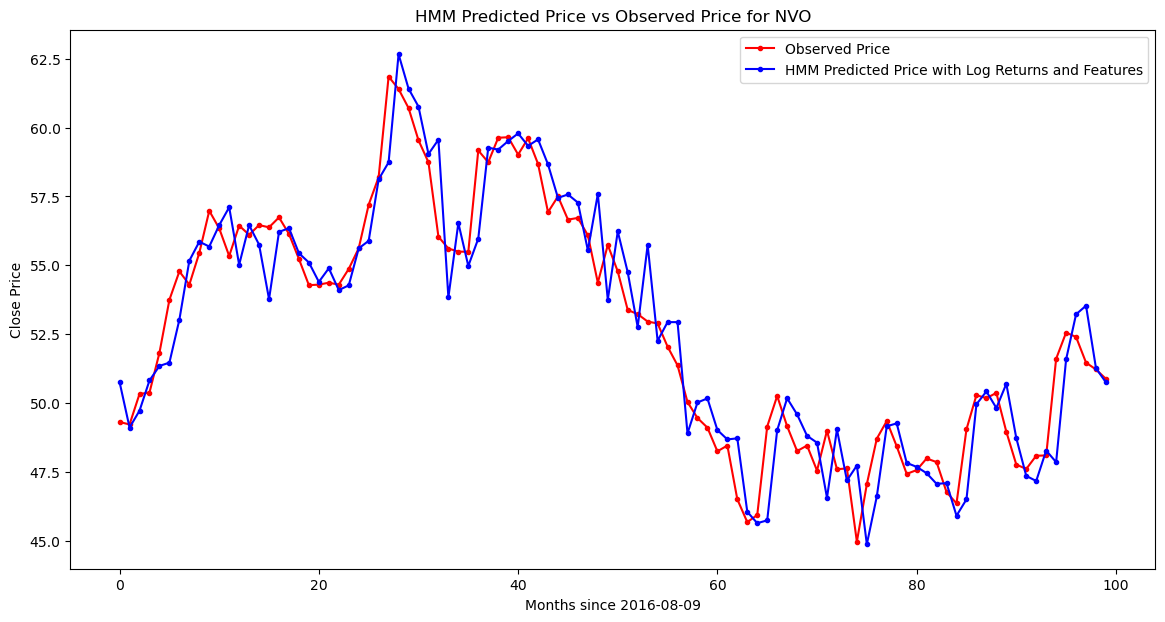

In [54]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual prices for the corresponding period
ax.plot(real[-100:], marker='.', label='Observed Price', color='red')
# ax.plot(NVO_predictions[-100:], marker='.', label='HMM Predicted Price with Sample Returns', color='blue')
# ax.plot(NVO_predictions_feat[-100:], marker='.', label='HMM Predicted Price with Features', color='green')
# ax.plot(NVO_predictions_log[-100:], marker='.', label='HMM Predicted Price with Log Returns', color='black')
# ax.plot(NVO_predictions_broadcast[-100:], marker='.', label='HMM Predicted Price with Broadcast', color='purple')
ax.plot(NVO_predictions_logfeat[-100:], marker='.', label='HMM Predicted Price with Log Returns and Features', color='blue')
ax.set_ylabel("Close Price")
ax.set_xlabel(f"Months since {df_nvo['Date'].iloc[150]}")
ax.legend();
ax.set_title(f"HMM Predicted Price vs Observed Price for NVO");

## Model evaluation

Finally, we will evaluate the performance of each model using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Direction Accuracy.

In [50]:
# Convert lists to numpy arrays
realPrices = [real, real_feat, real_log, real_broadcast, real_logfeat]
predictions = [NVO_predictions, NVO_predictions_feat, NVO_predictions_log, NVO_predictions_broadcast, NVO_predictions_logfeat]
modelNames = ['Sample Returns', 'Features', 'Log Returns', 'Broadcast', 'Log Returns and Features']

for i, (close, hmm_price) in enumerate(zip(realPrices, predictions)):
    mape_hmm = mape(close, hmm_price)
    rmse_hmm = rmse(close, hmm_price)
    direction_accuracy_hmm = direction_accuracy(close, hmm_price)
    print(f"Evaluation Metrics for HMM {modelNames[i]}:")
    print(f"Mean Absolute Percentage Error:", mape_hmm)
    print(f"Root Mean Squared Error:", rmse_hmm)
    print(f"Direction Accuracy: ", direction_accuracy_hmm, "\n")

Evaluation Metrics for HMM Sample Returns:
Mean Absolute Percentage Error: 0.017892734332305885
Root Mean Squared Error: 1.5378046512962091
Direction Accuracy:  0.5157496850062999 

Evaluation Metrics for HMM Features:
Mean Absolute Percentage Error: 0.018747849170103956
Root Mean Squared Error: 1.7104953538960705
Direction Accuracy:  0.5037942664418212 

Evaluation Metrics for HMM Log Returns:
Mean Absolute Percentage Error: 0.018109260956843818
Root Mean Squared Error: 1.5788073354335324
Direction Accuracy:  0.5073498530029399 

Evaluation Metrics for HMM Broadcast:
Mean Absolute Percentage Error: 0.013312057866408995
Root Mean Squared Error: 1.278521474472465
Direction Accuracy:  0.49601007979840406 

Evaluation Metrics for HMM Log Returns and Features:
Mean Absolute Percentage Error: 0.017996296243042206
Root Mean Squared Error: 1.524937607932956
Direction Accuracy:  0.5012647554806071 



## Optimization

In [42]:
def evaluate_params(df, Ntrain, Nwindow, NStates):
    real, pred, _ = HMM_predict_log_feat(
        df,
        train_size=Ntrain,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    m = mape(real, pred)
    r = rmse(real, pred)
    d = direction_accuracy(real, pred)
    print(f"MAPE: {m}, RMSE: {r}, Direction Accuracy: {d}")

In [44]:
import optuna

def objective(trial):
    Ntrain = trial.suggest_int("Ntrain", 100, 200)
    Nwindow = trial.suggest_int("Nwindow", 15, 50)
    NStates = trial.suggest_int("NStates", 4, 8)
    
    real, pred, _ = HMM_predict_log_feat(
        df_nvoV2,
        train_size=Ntrain,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    return mape(real, pred) + rmse(real, pred) - direction_accuracy(real, pred)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print(study.best_params)

[I 2026-03-20 16:42:02,505] A new study created in memory with name: no-name-d63ac914-714b-49d4-985d-a5a2bf543446
[I 2026-03-20 16:42:03,671] Trial 0 finished with value: 1.0545197277089564 and parameters: {'Ntrain': 110, 'Nwindow': 36, 'NStates': 6}. Best is trial 0 with value: 1.0545197277089564.
[I 2026-03-20 16:42:04,672] Trial 1 finished with value: 1.0816705629527181 and parameters: {'Ntrain': 182, 'Nwindow': 26, 'NStates': 7}. Best is trial 0 with value: 1.0545197277089564.
[I 2026-03-20 16:42:05,700] Trial 2 finished with value: 1.2117601636491477 and parameters: {'Ntrain': 119, 'Nwindow': 30, 'NStates': 8}. Best is trial 0 with value: 1.0545197277089564.
[I 2026-03-20 16:42:06,677] Trial 3 finished with value: 1.2149266017501357 and parameters: {'Ntrain': 150, 'Nwindow': 19, 'NStates': 4}. Best is trial 0 with value: 1.0545197277089564.
[I 2026-03-20 16:42:07,645] Trial 4 finished with value: 1.1694000447873694 and parameters: {'Ntrain': 174, 'Nwindow': 28, 'NStates': 4}. Best

{'Ntrain': 131, 'Nwindow': 41, 'NStates': 8}


In [46]:
evaluate_params(df_nvoV2, study.best_params["Ntrain"], study.best_params["Nwindow"], study.best_params["NStates"])

MAPE: 0.017965458957776157, RMSE: 1.524937607932956, Direction Accuracy: 0.5012647554806071


# Bonus

In [26]:
def HMM_predictV2(obsData, train_size, window_size, Ncomp):
    obs = obsData.copy()
    train = obs[:train_size]
    train_data = train['Return'].values.reshape(-1, 1)
    # Train global HMM
    model = hmm.GaussianHMM(n_components=Ncomp, random_state=123)
    model.fit(train_data)
    
    means = model.means_
    stds = np.sqrt(model._covars_)
    print("The means are:", np.round(means.flatten(), 3))
    print("The standard deviations are:", np.round(stds.flatten(), 2))


    print(np.round(model.transmat_, 2))
    
    first = True
    T = max(window_size, train_size)
    predictions = []
    returns = []
    while T < len(obs):
        window = obs[['Return']].iloc[T-window_size:T]

        # Probability distribution of hidden states for current step
        current_state = model.predict(window)[-1]

        # Expected distribution of hidden states for next step
        next_state = np.random.choice(len(means), p=model.transmat_[current_state])

        # Expected return across all states
        predicted_return = norm.rvs(loc=means[next_state], scale=stds[next_state], size=1, random_state=123)
        

        # Convert to price
        predicted_price = obs['Close'].iloc[T-1] * (1 + predicted_return)
        if first:
            print(f"Date for day before first prediction: {obs['Date'].iloc[T-1]}")
            print(f"Date for first day of real data: {obs['Date'].iloc[train_size]}")
            first = False

        returns.append(predicted_return[0])
        predictions.append(predicted_price)
        T += 1

    close = obs['Close'].iloc[train_size:].values

    return predictions, close, returns